# Jane Street — “‘Pent-Up’ Frustration 3 / Knight Moves 7”

## **Answer: `33609`**

*July 2026 puzzle · [statement](https://www.janestreet.com/puzzles/pent-up-frustration-3-knight-moves-7-index/) · [official solution](https://www.janestreet.com/puzzles/pent-up-frustration-3-knight-moves-7-solution/)*

---

This notebook solves the puzzle end to end, and it is written to be **read**, not
just run. Every step is derived rather than asserted:

| § | What happens |
|---|---|
| 1 | Restate the puzzle, then **read the board off the image** by measuring which grid lines are drawn thick |
| 2 | Prove that a “0-1-2 in three dimensions” move collapses into exactly **two** move types |
| 3 | Turn the scoring rule into code, and notice why the score sits at 0 for a while |
| 4 | Deduce the recording schedule: 12 printed numbers ⇒ 7 early records + 5 late ones ⇒ strong bounds on *K* |
| 5 | Search — a DFS that **never enumerates tower placements**; each move *forces* them instead |
| 6 | The single surviving walk: 54 moves, plus pictures |
| 7 | Fill in every visited square, find the 9 unvisited ones, sum their neighbour sums |
| 8 | An independent verification pass that re-checks every sentence of the statement |

The whole search finishes in a couple of seconds.

## 1. The puzzle

![the board](board.png)

> The board above has been tiled with the 12 pentominoes (plus a 2-by-2
> tetromino) into 13 regions. Think of each of these 13 regions as constructed
> out of 1-by-1-by-1 cubes. We need to add a **tower** to each region. A tower is
> an additional size-1 cube placed on one of a region’s squares.
>
> After adding these towers, place a knight at the **bottom-left square**. It then
> proceeds to make knight’s moves until it has visited all the towers. It never
> visits the same space twice. (A *move* on this board involves travelling 0 units
> in one dimension, 1 in another, and 2 in the third. The knight is allowed to
> “pass through” towers as it moves.)
>
> But here’s a catch: As you can see, the knight starts with a score of 0. On its
> *N*th move, its score increases by *N* if the move is to a location at the same
> altitude as the square it moved from. If, instead, it moves up, the score is
> multiplied by *N*. And finally, if it moves down, the score is divided by *N*.
> This last type of move is only allowed if the score is evenly divisible by *N*.
>
> Every three moves, up until move #18, the knight wrote down its score upon
> arriving at a given square. From then on it only wrote down its score every *K*
> moves, for some larger value *K*. Using this information, **can you reconstruct
> the knight’s path?**
>
> After filling all the remaining visited squares with the missing score values,
> find the *unvisited* squares. For each of these squares, compute the sum of the
> scores in any orthogonally adjacent squares that were part of the knight’s path.
> The answer to this puzzle is the sum of these “neighbor sums” from the unvisited
> squares.

### Notation used throughout

* Cells are indexed `i = 8*row + col` with **row 0 at the top**, so `i = 56` is the
  bottom-left starting square.
* Human-readable names are chess-style: column `a`–`h` left to right, rank `1`–`8`
  bottom to top. The knight starts on **a1**.

In [1]:
import base64, io, itertools, json, time
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

N = 8                      # board side
NCELLS = N * N

def rc(i):                 # cell index -> (row, col), row 0 = top
    return divmod(i, N)

def idx(r, c):
    return r * N + c

def name(i):               # cell index -> chess-style square name
    r, c = rc(i)
    return f"{'abcdefgh'[c]}{N - r}"

def grid_str(values, width=6, blank="."):
    """Render a dict {cell: value} as an 8x8 text grid (rank 8 on top)."""
    return "\n".join(
        " ".join(str(values.get(idx(r, c), blank)).rjust(width) for c in range(N))
        for r in range(N)
    )

print("helpers ready — bottom-left square is index", idx(7, 0), "=", name(idx(7, 0)))

helpers ready — bottom-left square is index 56 = a1


### 1a. Reading the tiling off the image

The region boundaries are the **thick** lines in the picture; ordinary cell
separators are thin. So rather than transcribing 64 letters by eye (and risking a
silent typo that would poison everything downstream), we measure the image.

The plan: locate the 9 vertical and 9 horizontal grid lines by looking for
columns/rows of the bitmap that are almost entirely dark, then for each *internal*
edge check whether the ink is ~4 px wide (thick, a region border) or ~1 px wide
(thin, same region).

In [2]:
img = np.array(Image.open("board.png").convert("L"))
dark = img < 128
print("image:", img.shape)

board_rows = dark[:460, :]                 # the grid lives in the top ~460 px
col_ink = board_rows.sum(axis=0)
row_ink = board_rows.sum(axis=1)

def line_positions(ink, threshold):
    """Group consecutive high-ink indices and keep the darkest of each group."""
    hits = [i for i, v in enumerate(ink) if v > threshold]
    groups, cur = [], [hits[0]]
    for i in hits[1:]:
        if i - cur[-1] <= 2:
            cur.append(i)
        else:
            groups.append(cur); cur = [i]
    groups.append(cur)
    return [max(g, key=lambda i: ink[i]) for g in groups]

XS = line_positions(col_ink, 380)          # 9 vertical grid lines
YS = line_positions(row_ink, 380)          # 9 horizontal grid lines
print("vertical   x =", XS)
print("horizontal y =", YS)
assert len(XS) == len(YS) == N + 1
print("cell size:", np.diff(XS), np.diff(YS))

image: (807, 800)
vertical   x = [205, 255, 305, 355, 405, 455, 505, 555, 604]
horizontal y = [35, 85, 135, 185, 235, 285, 335, 385, 434]
cell size: [50 50 50 50 50 50 50 49] [50 50 50 50 50 50 50 49]


In [3]:
def edge_is_thick(kind, r, c):
    """Is the border between two neighbouring cells drawn thick?

    kind 'V': the vertical line x = XS[c], between cells (r, c-1) and (r, c).
    kind 'H': the horizontal line y = YS[r], between cells (r-1, c) and (r, c).
    A thick line is ~4 px wide, so pixels 2 away from the centre are still dark;
    a thin line is 1 px, so they are white.
    """
    if kind == "V":
        xb = XS[c]
        span = range(YS[r] + 8, YS[r] + 43)          # skip the corners
        plus = sum(dark[y, xb + 2] for y in span)
        minus = sum(dark[y, xb - 2] for y in span)
    else:
        yb = YS[r]
        span = range(XS[c] + 8, XS[c] + 43)
        plus = sum(dark[yb + 2, x] for x in span)
        minus = sum(dark[yb - 2, x] for x in span)
    n = len(span)
    return plus > 0.7 * n or minus > 0.7 * n

print("thick vertical borders (T = region boundary), columns 1..7")
for r in range(N):
    print(" ", " ".join("T" if edge_is_thick("V", r, c) else "." for c in range(1, N)))
print("\nthick horizontal borders, rows 1..7")
for r in range(1, N):
    print(" ", " ".join("T" if edge_is_thick("H", r, c) else "." for c in range(N)))

thick vertical borders (T = region boundary), columns 1..7
  . . . . T . .
  . . T . T . T
  T T T . . T T
  T . T . T T .
  . T T . T . T
  T T T T . T T
  T T . . T . T
  . . T T . T .

thick horizontal borders, rows 1..7
  T T T T T T T .
  . T . . . T . .
  T . T T T T . T
  . T . . . . T T
  . T . T T . T .
  . . T . T T . .
  T . T . T . T .


In [4]:
# Union cells that are NOT separated by a thick line -> connected regions.
parent = list(range(NCELLS))

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    a, b = find(a), find(b)
    if a != b:
        parent[a] = b

for r in range(N):
    for c in range(1, N):
        if not edge_is_thick("V", r, c):
            union(idx(r, c - 1), idx(r, c))
for r in range(1, N):
    for c in range(N):
        if not edge_is_thick("H", r, c):
            union(idx(r - 1, c), idx(r, c))

groups = defaultdict(list)
for i in range(NCELLS):
    groups[find(i)].append(i)
groups = sorted(groups.values(), key=min)          # deterministic ordering
LETTERS = "ABCDEFGHIJKLM"
assert len(groups) == 13, len(groups)

REGION = [None] * NCELLS
for g, cells in enumerate(groups):
    for i in cells:
        REGION[i] = g
REGION_ROWS = tuple("".join(LETTERS[REGION[idx(r, c)]] for c in range(N)) for r in range(N))

print(f"{len(groups)} regions, sizes {sorted(len(g) for g in groups)}\n")
for row in REGION_ROWS:
    print(" ", row)

13 regions, sizes [4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]

  AAAAABBB
  CCCDDEEB
  CFCDDDEB
  GFFHHIEE
  GGFHHIIJ
  GKFLIIMJ
  GKLLLMMJ
  KKKLMMJJ


### 1b. Sanity check: is this really the 12 pentominoes plus a 2×2?

This is the single most valuable check in the notebook. If the border detection
had mis-read even one edge, the 13 shapes would *not* come out as the twelve
distinct pentominoes plus one square tetromino — the odds of a wrong reading
landing on exactly that set by luck are negligible.

In [5]:
PIECES = {
    "F": [(0, 1), (0, 2), (1, 0), (1, 1), (2, 1)],
    "I": [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0)],
    "L": [(0, 0), (1, 0), (2, 0), (3, 0), (3, 1)],
    "N": [(0, 1), (1, 1), (2, 0), (2, 1), (3, 0)],
    "P": [(0, 0), (0, 1), (1, 0), (1, 1), (2, 0)],
    "T": [(0, 0), (0, 1), (0, 2), (1, 1), (2, 1)],
    "U": [(0, 0), (0, 2), (1, 0), (1, 1), (1, 2)],
    "V": [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2)],
    "W": [(0, 0), (1, 0), (1, 1), (2, 1), (2, 2)],
    "X": [(0, 1), (1, 0), (1, 1), (1, 2), (2, 1)],
    "Y": [(0, 1), (1, 0), (1, 1), (2, 1), (3, 1)],
    "Z": [(0, 0), (0, 1), (1, 1), (2, 1), (2, 2)],
    "O (2x2 tetromino)": [(0, 0), (0, 1), (1, 0), (1, 1)],
}

def normalise(cells):
    r0 = min(r for r, _ in cells); c0 = min(c for _, c in cells)
    return tuple(sorted((r - r0, c - c0) for r, c in cells))

def orientations(cells):
    """All 8 rotations/reflections, normalised."""
    out, cur = set(), list(cells)
    for flip in (False, True):
        shape = [(r, -c) for r, c in cur] if flip else cur
        for _ in range(4):
            shape = [(c, -r) for r, c in shape]
            out.add(normalise(shape))
    return out

CATALOGUE = {o: nm for nm, cells in PIECES.items() for o in orientations(cells)}

print(f"{'region':<7}{'size':<6}{'piece':<20}squares")
found = []
for g, cells in enumerate(groups):
    shape = normalise([rc(i) for i in cells])
    piece = CATALOGUE.get(shape, "*** UNKNOWN ***")
    found.append(piece)
    print(f"{LETTERS[g]:<7}{len(cells):<6}{piece:<20}"
          + " ".join(name(i) for i in sorted(cells)))

assert sorted(found) == sorted(PIECES), "the 13 shapes are not the expected set!"
print("\nOK: exactly the 12 distinct pentominoes + one 2x2 tetromino, each used once.")

region size  piece               squares
A      5     I                   a8 b8 c8 d8 e8
B      5     V                   f8 g8 h8 h7 h6
C      5     U                   a7 b7 c7 a6 c6
D      5     P                   d7 e7 d6 e6 f6
E      5     Z                   f7 g7 g6 g5 h5
F      5     N                   b6 b5 c5 c4 c3
G      5     Y                   a5 a4 b4 a3 a2
H      4     O (2x2 tetromino)   d5 e5 d4 e4
I      5     F                   f5 f4 g4 e3 f3
J      5     L                   h4 h3 h2 g1 h1
K      5     T                   b3 b2 a1 b1 c1
L      5     X                   d3 c2 d2 e2 d1
M      5     W                   g3 f2 g2 e1 f1

OK: exactly the 12 distinct pentominoes + one 2x2 tetromino, each used once.


### 1c. The twelve printed numbers

Which cells contain ink (away from the borders) tells us *where* the numbers are;
the values themselves are transcribed from the picture.

In [6]:
ink = {}
for r in range(N):
    for c in range(N):
        block = dark[YS[r] + 8:YS[r] + 43, XS[c] + 8:XS[c] + 43]
        if block.sum() > 20:
            ink[idx(r, c)] = int(block.sum())
print("cells containing ink (pixel counts):")
print(grid_str({k: v for k, v in ink.items()}, width=5, blank="."))

GIVEN = {
    idx(0, 5): 37,   idx(0, 7): 1100,
    idx(2, 3): 23,   idx(2, 5): 138,
    idx(3, 0): 528,
    idx(4, 1): 449,  idx(4, 4): 16,
    idx(5, 1): 750,  idx(5, 3): 88,
    idx(5, 5): 272,  idx(5, 6): 1,
    idx(7, 0): 0,
}
START = idx(7, 0)
assert set(GIVEN) == set(ink), "transcribed cells disagree with the detected ink"
assert GIVEN[START] == 0 and START == idx(7, 0)
print(f"\n{len(GIVEN)} printed numbers, positions confirmed against the image.")
print("start square:", name(START), "with printed score", GIVEN[START])

cells containing ink (pixel counts):
    .     .     .     .     .   212     .   144
    .     .     .     .     .     .     .     .
    .     .     .   247     .   135     .     .
  170     .     .     .     .     .     .     .
    .   146     .     .   210     .     .     .
    .   141     .   282     .   139    60     .
    .     .     .     .     .     .     .     .
  117     .     .     .     .     .     .     .

12 printed numbers, positions confirmed against the image.
start square: a1 with printed score 0


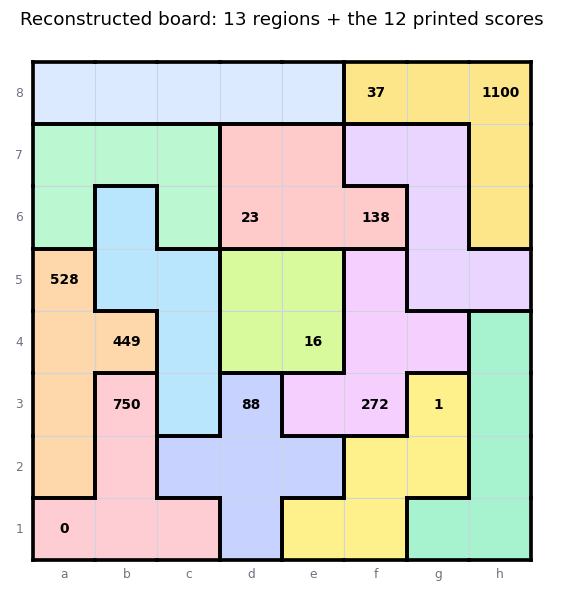

In [7]:
REGION_COLOURS = ["#dbeafe", "#fde68a", "#bbf7d0", "#fecaca", "#e9d5ff", "#bae6fd",
                  "#fed7aa", "#d9f99d", "#f5d0fe", "#a7f3d0", "#fecdd3", "#c7d2fe",
                  "#fef08a"]

def draw_board(ax, cell_text=None, colour_regions=False, shade=(), towers=(),
               path=None, title="", fontsize=9, textcolour=None):
    ax.set_xlim(-0.35, N + 0.35); ax.set_ylim(-0.35, N + 0.35)
    ax.set_aspect("equal"); ax.axis("off")
    if title:
        ax.set_title(title, fontsize=12, pad=10)

    for i in range(NCELLS):
        r, c = rc(i)
        face = "white"
        if colour_regions:
            face = REGION_COLOURS[REGION[i]]
        if i in shade:
            face = "#9ca3af"
        ax.add_patch(Rectangle((c, N - 1 - r), 1, 1, facecolor=face,
                               edgecolor="#cbd5e1", lw=0.7, zorder=1))
    # thick region borders
    for r in range(N):
        for c in range(N):
            g = REGION_ROWS[r][c]
            x, y = c, N - 1 - r
            if c == N - 1 or REGION_ROWS[r][c + 1] != g:
                ax.plot([x + 1, x + 1], [y, y + 1], color="black", lw=2.4, zorder=4)
            if c == 0 or REGION_ROWS[r][c - 1] != g:
                ax.plot([x, x], [y, y + 1], color="black", lw=2.4, zorder=4)
            if r == 0 or REGION_ROWS[r - 1][c] != g:
                ax.plot([x, x + 1], [y + 1, y + 1], color="black", lw=2.4, zorder=4)
            if r == N - 1 or REGION_ROWS[r + 1][c] != g:
                ax.plot([x, x + 1], [y, y], color="black", lw=2.4, zorder=4)
    for i in towers:                                  # towers: a small dark square
        r, c = rc(i)
        ax.add_patch(Rectangle((c + 0.06, N - 1 - r + 0.06), 0.20, 0.20,
                               facecolor="#1f2937", edgecolor="none", zorder=6))
    if path:
        cmap = plt.get_cmap("plasma")
        span = max(len(path) - 2, 1)
        for k, (a, b) in enumerate(zip(path, path[1:])):
            ra, ca = rc(a); rb, cb = rc(b)
            ax.annotate("", xy=(cb + 0.5, N - 0.5 - rb), xytext=(ca + 0.5, N - 0.5 - ra),
                        arrowprops=dict(arrowstyle="-|>", lw=1.4,
                                        color=cmap(0.08 + 0.82 * k / span),
                                        alpha=0.95, shrinkA=8, shrinkB=8),
                        zorder=5)
    for i, txt in (cell_text or {}).items():
        r, c = rc(i)
        col = textcolour(i) if callable(textcolour) else (textcolour or "black")
        ax.text(c + 0.5, N - 0.5 - r, str(txt), ha="center", va="center",
                fontsize=fontsize, color=col, zorder=7,
                fontweight="bold" if i in GIVEN else "normal")
    for c in range(N):
        ax.text(c + 0.5, -0.22, "abcdefgh"[c], ha="center", va="center",
                fontsize=8, color="#6b7280")
    for r in range(N):
        ax.text(-0.22, N - 0.5 - r, str(N - r), ha="center", va="center",
                fontsize=8, color="#6b7280")

fig, ax = plt.subplots(figsize=(6.4, 6.4))
draw_board(ax, cell_text=GIVEN, colour_regions=True,
           title="Reconstructed board: 13 regions + the 12 printed scores")
plt.show()

## 2. What is a move, really?

Each region is one layer of cubes, and each region gets **one** extra cube. So the
surface the knight walks on has only two possible altitudes:

$$\text{alt}(s) = \begin{cases} 2 & s \text{ is its region's tower}\\ 1 & \text{otherwise}\end{cases}
\qquad\Longrightarrow\qquad |\Delta z| \in \{0, 1\}.$$

A move travels $0$, $1$ and $2$ units along the three axes in some order. Let's
enumerate the six assignments and throw away the impossible ones.

In [8]:
print(f"{'|dr|':>4} {'|dc|':>4} {'|dz|':>4}   verdict")
for dr, dc, dz in sorted(set(itertools.permutations((0, 1, 2)))):
    if dz == 2:
        verdict = "impossible: altitudes are only 1 or 2, so |dz| <= 1"
    elif dz == 0:
        verdict = "LEVEL move: an ordinary knight's move, altitude unchanged"
    else:
        verdict = "FLIP move: straight jump of 2, altitude changes by 1"
    print(f"{dr:>4} {dc:>4} {dz:>4}   {verdict}")

|dr| |dc| |dz|   verdict
   0    1    2   impossible: altitudes are only 1 or 2, so |dz| <= 1
   0    2    1   FLIP move: straight jump of 2, altitude changes by 1
   1    0    2   impossible: altitudes are only 1 or 2, so |dz| <= 1
   1    2    0   LEVEL move: an ordinary knight's move, altitude unchanged
   2    0    1   FLIP move: straight jump of 2, altitude changes by 1
   2    1    0   LEVEL move: an ordinary knight's move, altitude unchanged


So there are exactly **two** kinds of move:

| kind | board displacement | altitude |
|---|---|---|
| **LEVEL** | $(\pm1,\pm2)$ or $(\pm2,\pm1)$ — a normal knight's move | must be **equal** at both ends |
| **FLIP** | $(0,\pm2)$ or $(\pm2,0)$ — two squares in a straight line | must **differ by exactly 1** |

And here is the observation the whole solution rests on. Because altitudes live in
$\{1,2\}$, a FLIP move is not merely *allowed* to change altitude — its destination
is **forced**:

* standing at altitude 1, a FLIP must go **up**, so the destination *is* its
  region’s tower (score $\times N$);
* standing on a tower, a FLIP must go **down**, so the destination is *not* a tower
  (score $\div N$).

A LEVEL move copies the current altitude to the destination. Therefore **the walk
itself dictates which squares are towers** — we never have to guess a tower layout.

In [9]:
LEVEL_DELTAS = [(1, 2), (2, 1), (-1, 2), (-2, 1), (1, -2), (2, -1), (-1, -2), (-2, -1)]
FLIP_DELTAS = [(0, 2), (0, -2), (2, 0), (-2, 0)]

MOVES = [[] for _ in range(NCELLS)]        # MOVES[i] = [(destination, flips), ...]
for i in range(NCELLS):
    r, c = rc(i)
    for flips, deltas in ((0, LEVEL_DELTAS), (1, FLIP_DELTAS)):
        for dr, dc in deltas:
            nr, nc = r + dr, c + dc
            if 0 <= nr < N and 0 <= nc < N:
                MOVES[i].append((idx(nr, nc), flips))

deg = {i: len(MOVES[i]) for i in range(NCELLS)}
print("out-degree per square (level + flip options):")
print(grid_str(deg, width=3))
print("\ntotal directed moves:", sum(deg.values()),
      "| from the start square a1:", [(name(d), "flip" if f else "level")
                                      for d, f in MOVES[START]])

out-degree per square (level + flip options):
  4   5   7   7   7   7   5   4
  5   6   9   9   9   9   6   5
  7   9  12  12  12  12   9   7
  7   9  12  12  12  12   9   7
  7   9  12  12  12  12   9   7
  7   9  12  12  12  12   9   7
  5   6   9   9   9   9   6   5
  4   5   7   7   7   7   5   4

total directed moves: 528 | from the start square a1: [('c2', 'level'), ('b3', 'level'), ('c1', 'flip'), ('a3', 'flip')]


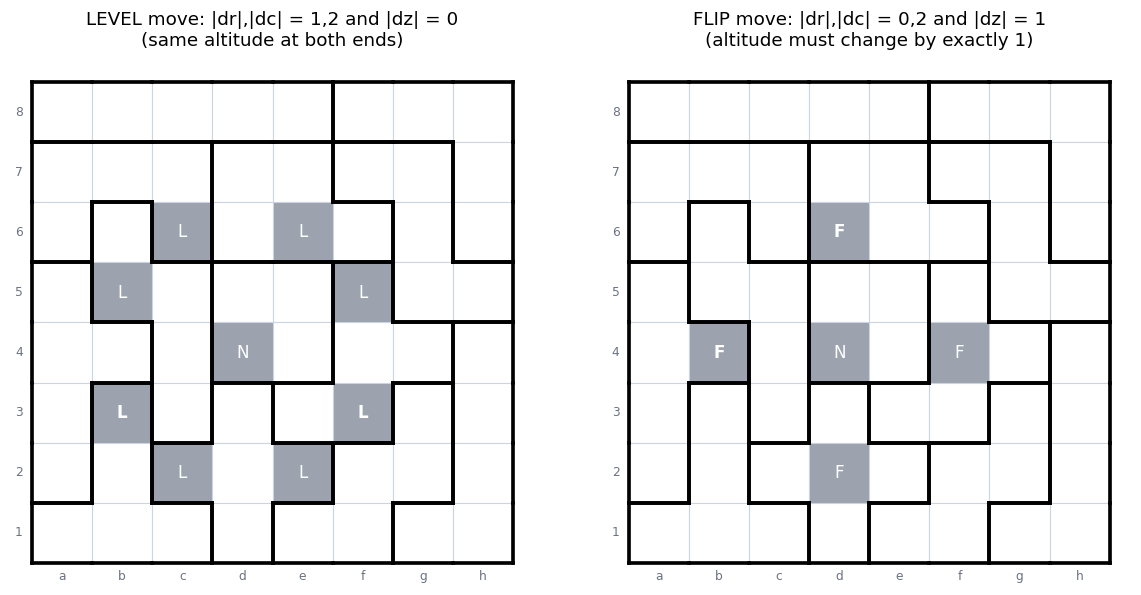

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.4))
demo = idx(4, 3)                                    # d4
for ax, (which, flips, label) in zip(axes, [
        ("LEVEL", 0, "LEVEL move: |dr|,|dc| = 1,2 and |dz| = 0\n(same altitude at both ends)"),
        ("FLIP", 1, "FLIP move: |dr|,|dc| = 0,2 and |dz| = 1\n(altitude must change by exactly 1)")]):
    targets = {d: which[0] for d, f in MOVES[demo] if f == flips}
    draw_board(ax, cell_text={**targets, demo: "N"},
               shade=set(targets) | {demo}, title=label, fontsize=11,
               textcolour="white")
plt.tight_layout(); plt.show()

## 3. Scoring

Move $N$ updates the running score $s$:

$$s \;\mapsto\; \begin{cases}
s + N & \text{LEVEL move}\\
s \times N & \text{FLIP move going up (onto a tower)}\\
s / N & \text{FLIP move going down — only if } N \mid s
\end{cases}$$

Two immediate consequences worth keeping in mind:

1. The score starts at **0**, and $0 \times N = 0$ and $0 / N = 0$. So the score is
   stuck at 0 until the first LEVEL move, no matter how much the knight climbs.
2. A `/N` move is a hard constraint, not a choice — it prunes ferociously.

For example, `1` is printed on **g3**, and the only recording move that early is
move #3; a three-move opening that lands on a score of exactly 1 has to look like
$0 \xrightarrow{+1} 1 \xrightarrow{+2} 3 \xrightarrow{\div 3} 1$.

In [11]:
def apply_move(score, n, flips, going_up):
    """Return the new score, or None if the move is illegal."""
    if not flips:
        return score + n
    if going_up:
        return score * n
    return None if score % n else score // n

demo_ops = [("+", 1), ("+", 2), ("/", 3)]
s = 0
print("score walk-through for the opening that produces the printed 1 on g3:")
for k, (op, n) in enumerate(demo_ops, start=1):
    s = apply_move(s, n, flips=(op != "+"), going_up=False)
    print(f"  move {n}: {op}{n} -> {s}")
print("\nand notice how climbing first keeps you at zero:")
s = 0
for n in (1, 2):
    s = apply_move(s, n, flips=True, going_up=True)
    print(f"  move {n}: x{n} -> {s}")

score walk-through for the opening that produces the printed 1 on g3:
  move 1: +1 -> 1
  move 2: +2 -> 3
  move 3: /3 -> 1

and notice how climbing first keeps you at zero:
  move 1: x1 -> 0
  move 2: x2 -> 0


## 4. Decoding the recording schedule

The knight recorded its score at moves $0, 3, 6, 9, 12, 15, 18$ — that is **7**
records — and afterwards every $K$ moves, i.e. at $18+K, 18+2K, \dots$

Exactly **12** numbers are printed, so there are exactly **5** late records:

$$\text{records} = \{0,3,6,9,12,15,18\} \cup \{18 + jK : j = 1,\dots,5\}.$$

Let $L$ be the number of moves the knight makes. The 5th late record must happen,
and the 6th must not:

$$18 + 5K \;\le\; L \;<\; 18 + 6K .$$

That gives a second, very sharp constraint: since no square is repeated,
$L \le 63$, so $18 + 5K \le 63 \Rightarrow K \le 9$. The statement says $K$ is
“some larger value”, i.e. $K > 3$, leaving only $K \in \{4,\dots,9\}$ — and we will
in fact test $K = 1..12$ so that nothing is assumed.

One more constraint that does an enormous amount of work: a printed number *is* the
score at the moment the knight arrived there. So the knight steps on a printed
square **exactly** on recording moves, and never on any other move.

In [12]:
def record_moves(K):
    """(set of recording move indices, smallest legal L, largest legal L)."""
    records = set(range(0, 19, 3)) | {18 + j * K for j in range(1, 6)}
    return records, 18 + 5 * K, 18 + 6 * K - 1

print(f"{'K':>3} {'#records':>9}  {'L window':>12}  feasible?")
for K in range(1, 13):
    recs, lo, hi = record_moves(K)
    ok = "yes" if (len(recs) == 12 and lo <= 63) else "no"
    print(f"{K:>3} {len(recs):>9}  {f'{lo}..{hi}':>12}  {ok}")

  K  #records      L window  feasible?
  1        12        23..23  yes
  2        12        28..29  yes
  3        12        33..35  yes
  4        12        38..41  yes
  5        12        43..47  yes
  6        12        48..53  yes
  7        12        53..59  yes
  8        12        58..65  yes
  9        12        63..71  yes
 10        12        68..77  no
 11        12        73..83  no
 12        12        78..89  no


## 5. The search

The naive framing is hopeless: choosing a tower square in each region is
$5^{12}\times 4 \approx 10^9$ layouts, each needing its own walk search.

Instead we let the walk decide. Carry, alongside the usual DFS state
(position, move number, score, visited set):

* `tower[g]` — the tower square of region `g`, or `-1` if still undecided;
* `excluded[g]` — a bitmask of squares in `g` **proven** to be plain height 1.

Entering a square at altitude 2 *assigns* that region’s tower (and fails if the
region already has one elsewhere, or if this square was already excluded).
Entering at altitude 1 *excludes* the square; if that exhausts a region’s five
squares, the branch is dead because the region could no longer host a tower.

Two more things fall out neatly:

* **“visits all the towers”** ⇔ every region has an assigned tower, because a tower
  only ever gets assigned by the knight standing on it. So the walk ends exactly
  when the 13th assignment happens — the count of assigned towers *is* the count of
  towers visited.
* **the printed-square rule** — on a recording move the destination must be a
  printed square whose number equals the new score; on any other move the
  destination must not be printed at all.

In [13]:
REGION_CELLS = [[i for i in range(NCELLS) if REGION[i] == g] for g in range(13)]
FULL_MASK = [sum(1 << i for i in cells) for cells in REGION_CELLS]
NUMBERED_MASK = sum(1 << i for i in GIVEN)

def solve(K, stats=None):
    """Every walk consistent with the puzzle for this K. Returns [(path, towers)]."""
    records, last_record, max_len = record_moves(K)
    solutions, path = [], [START]
    nodes = 0

    def dfs(pos, mv, score, visited, tower, excluded, alt, n_towers):
        nonlocal nodes
        nodes += 1
        if n_towers == 13:                      # all towers stood on -> walk stops
            if last_record <= mv <= max_len:
                solutions.append((path.copy(), tower.copy()))
            return
        if mv >= max_len:
            return
        nmv = mv + 1
        recording = nmv in records
        for nxt, flips in MOVES[pos]:
            if visited >> nxt & 1:
                continue
            if recording:
                if nxt not in GIVEN:
                    continue
            elif NUMBERED_MASK >> nxt & 1:
                continue
            n_alt = (3 - alt) if flips else alt          # 1 <-> 2
            g = REGION[nxt]
            n_tower, n_excl, n_cnt = tower, excluded, n_towers
            if n_alt == 2:                               # nxt must be g's tower
                if tower[g] != -1 or excluded[g] >> nxt & 1:
                    continue
                n_tower = tower.copy(); n_tower[g] = nxt; n_cnt += 1
            else:                                        # nxt must be plain
                if tower[g] == nxt:
                    continue
                if not (excluded[g] >> nxt & 1):
                    n_excl = excluded.copy()
                    n_excl[g] = excluded[g] | 1 << nxt
                    if tower[g] == -1 and n_excl[g] == FULL_MASK[g]:
                        continue                         # no room left for a tower
            n_score = apply_move(score, nmv, flips, n_alt == 2)
            if n_score is None:                          # score not divisible by N
                continue
            if recording and n_score != GIVEN[nxt]:
                continue
            path.append(nxt)
            dfs(nxt, nmv, n_score, visited | 1 << nxt, n_tower, n_excl, n_alt, n_cnt)
            path.pop()

    for start_alt in (1, 2):                    # is the start square itself a tower?
        tower, excluded = [-1] * 13, [0] * 13
        g = REGION[START]
        if start_alt == 2:
            tower[g], n_towers = START, 1
        else:
            excluded[g], n_towers = 1 << START, 0
        dfs(START, 0, 0, 1 << START, tower, excluded, start_alt, n_towers)
    if stats is not None:
        stats["nodes"] = nodes
    return solutions

In [14]:
all_solutions, total_nodes, t0 = [], 0, time.time()
print(f"{'K':>3} {'nodes':>12} {'solutions':>10}  {'seconds':>8}")
for K in range(1, 13):
    st, t = {}, time.time()
    sols = solve(K, stats=st)
    total_nodes += st["nodes"]
    print(f"{K:>3} {st['nodes']:>12,} {len(sols):>10}  {time.time() - t:>8.2f}")
    all_solutions += [(K, p, tw) for p, tw in sols]
print(f"\n{total_nodes:,} search nodes in {time.time() - t0:.1f}s "
      f"-> {len(all_solutions)} solution(s)")
assert len(all_solutions) == 1, "expected the puzzle to pin down a unique walk"
K, PATH, TOWER = all_solutions[0]
print(f"\nUNIQUE: K = {K}, {len(PATH) - 1} moves, {len(PATH)} squares visited")

  K        nodes  solutions   seconds
  1        1,108          0      0.00
  2        1,799          0      0.01
  3        4,389          0      0.02
  4       10,104          0      0.04
  5       25,268          0      0.08
  6       59,050          0      0.20
  7      687,095          1      2.04
  8      306,510          0      0.95
  9      675,592          0      1.96
 10    1,358,169          0      4.04
 11    2,734,055          0      7.74
 12    5,036,912          0     13.72

10,900,051 search nodes in 30.8s -> 1 solution(s)

UNIQUE: K = 7, 54 moves, 55 squares visited


## 6. The reconstructed walk

Now replay it from scratch — deliberately *not* reusing the search code — deriving
altitudes and scores again and asserting each rule as we go.

In [15]:
def replay(path, tower):
    alt = {path[0]: 2 if tower[REGION[path[0]]] == path[0] else 1}
    score = {path[0]: 0}
    s, log = 0, []
    for n in range(1, len(path)):
        p, q = path[n - 1], path[n]
        dr, dc = abs(rc(p)[0] - rc(q)[0]), abs(rc(p)[1] - rc(q)[1])
        aq = 2 if tower[REGION[q]] == q else 1
        dz = abs(aq - alt[p])
        assert sorted((dr, dc, dz)) == [0, 1, 2], f"move #{n} is not a legal move"
        if dz == 0:
            s += n; op = f"+{n}"
        elif aq > alt[p]:
            s *= n; op = f"x{n}"
        else:
            assert s % n == 0, f"move #{n} divides {s} by {n}"
            s //= n; op = f"/{n}"
        alt[q], score[q] = aq, s
        log.append((n, p, q, op, s))
    return alt, score, log

ALT, SCORE, LOG = replay(PATH, TOWER)
RECORDS, LAST_RECORD, MAX_LEN = record_moves(K)
WRITTEN = sorted(n for n in RECORDS if n <= len(PATH) - 1)

print("towers, one per region:")
print("  " + "   ".join(f"{LETTERS[g]}:{name(TOWER[g])}" for g in range(13)))
print(f"\nwalk ({len(PATH) - 1} moves):")
print("  " + " ".join(name(c) for c in PATH))
print(f"\nrecording moves: {WRITTEN}")
print(f"path length {len(PATH) - 1} lies in the required window "
      f"[{LAST_RECORD}, {MAX_LEN}]")

towers, one per region:
  A:d8   B:h6   C:b7   D:e6   E:f7   F:c4   G:a5   H:e5   I:e3   J:h3   K:a1   L:c2   M:e1

walk (54 moves):
  a1 c2 e3 g3 h1 f2 e4 e6 e8 d6 c8 a7 a5 b7 d8 f8 d7 c5 d3 b2 a4 c4 e5 f7 h7 f6 d5 c3 a2 c1 e1 g1 f3 h3 h5 g7 f5 e7 c6 b4 a6 c7 b5 a3 b1 d2 b3 d4 e2 f4 g2 h4 g6 h8 h6

recording moves: [0, 3, 6, 9, 12, 15, 18, 25, 32, 39, 46, 53]
path length 54 lies in the required window [53, 59]


In [16]:
print(f"{'move':>4}  {'from':>4} {'to':>4}  {'op':<5}{'alt':>4}  {'score':>8}  recorded")
print("-" * 58)
print(f"{0:>4}  {'':>4} {name(PATH[0]):>4}  {'':<5}{ALT[PATH[0]]:>4}  {0:>8}  <- 0")
for n, p, q, op, s in LOG:
    tag = f"<- {GIVEN[q]}" if n in WRITTEN else ""
    print(f"{n:>4}  {name(p):>4} {name(q):>4}  {op:<5}{ALT[q]:>4}  {s:>8}  {tag}")

move  from   to  op    alt     score  recorded
----------------------------------------------------------
   0         a1          2         0  <- 0
   1    a1   c2  +1      2         1  
   2    c2   e3  +2      2         3  
   3    e3   g3  /3      1         1  <- 1
   4    g3   h1  +4      1         5  
   5    h1   f2  +5      1        10  
   6    f2   e4  +6      1        16  <- 16
   7    e4   e6  x7      2       112  
   8    e6   e8  /8      1        14  
   9    e8   d6  +9      1        23  <- 23
  10    d6   c8  +10     1        33  
  11    c8   a7  +11     1        44  
  12    a7   a5  x12     2       528  <- 528
  13    a5   b7  +13     2       541  
  14    b7   d8  +14     2       555  
  15    d8   f8  /15     1        37  <- 37
  16    f8   d7  +16     1        53  
  17    d7   c5  +17     1        70  
  18    c5   d3  +18     1        88  <- 88
  19    d3   b2  +19     1       107  
  20    b2   a4  +20     1       127  
  21    a4   c4  x21     2      2667  
  

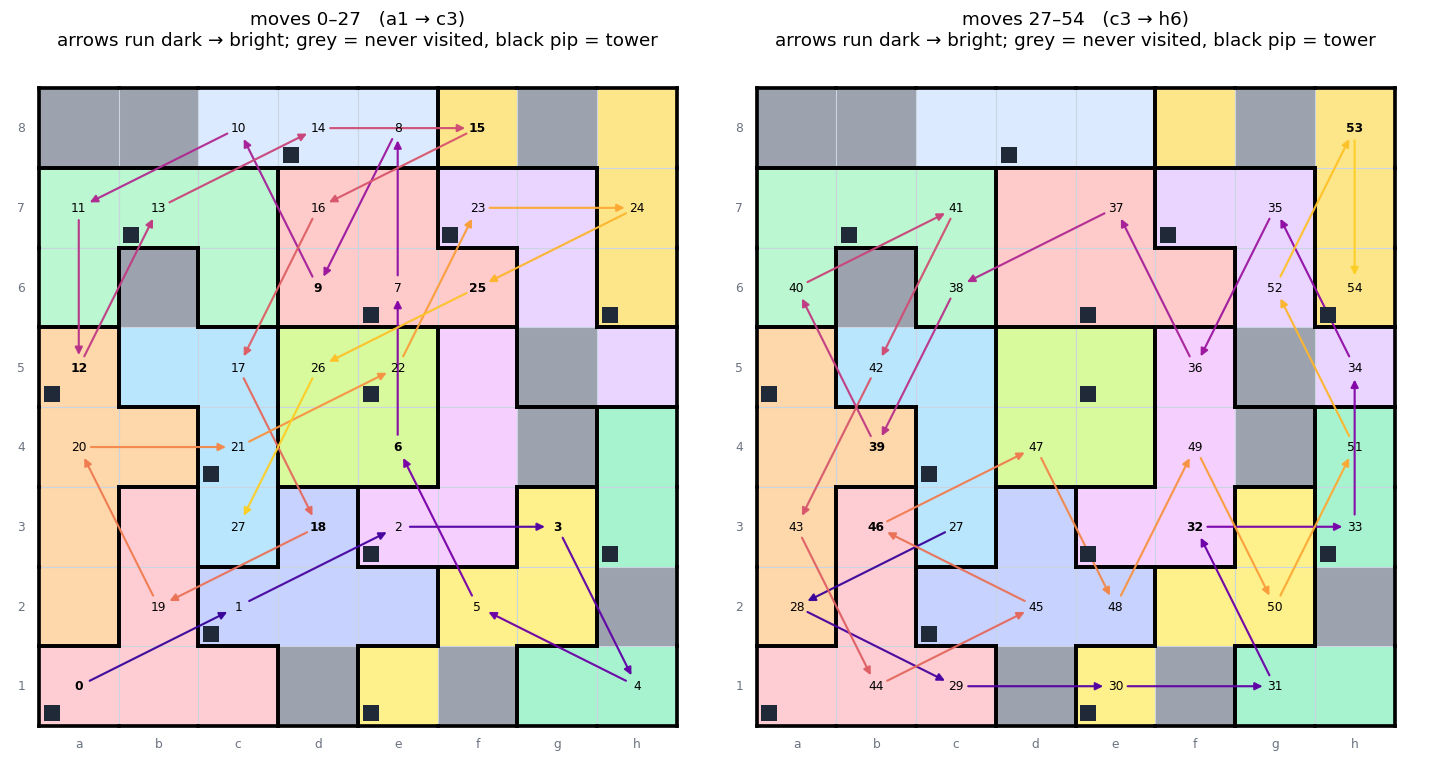

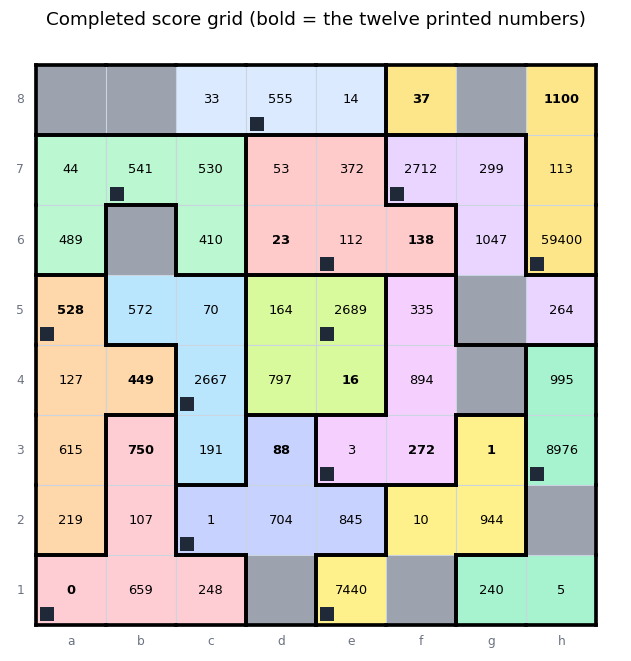

In [17]:
UNVISITED = sorted(set(range(NCELLS)) - set(PATH))
HALF = 27

fig, axes = plt.subplots(1, 2, figsize=(13.2, 6.8))
for ax, lo, hi in ((axes[0], 0, HALF), (axes[1], HALF, len(PATH) - 1)):
    leg = PATH[lo:hi + 1]
    draw_board(ax, cell_text={c: n for n, c in enumerate(PATH) if lo <= n <= hi},
               colour_regions=True, towers=TOWER, path=leg, shade=set(UNVISITED),
               fontsize=8,
               title=f"moves {lo}–{hi}   ({name(PATH[lo])} → {name(PATH[hi])})\n"
                     f"arrows run dark → bright; grey = never visited, "
                     f"black pip = tower")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7.2, 7.2))
draw_board(ax, cell_text=SCORE, colour_regions=True, towers=TOWER,
           shade=set(UNVISITED), fontsize=8.5,
           title="Completed score grid (bold = the twelve printed numbers)")
plt.show()

Reading the run: the start square **a1** is itself a tower, so the knight begins at
altitude 2. Two ordinary knight moves take it to e3 with a score of 3, and then a
straight two-square jump to g3 must come *down* — dividing by 3 and putting the
score back to the printed `1`. That pattern of climbing and diving keeps the score
small and awkward through the early records (note the `x7`/`÷8` pair and the
`x12 → 528` spike), after which the knight settles into a long stretch of LEVEL
moves quietly accumulating $+N$ from move 35 to move 53. The very last move is one
more climb, `x54`, which lands on **h6** — the 13th and final tower — so the walk
stops there with 59400 on the board.

## 7. The answer

Nine squares are never visited. For each, add up the scores of its orthogonally
adjacent squares **that the knight did visit**, then total those sums.

In [18]:
rows, answer = [], 0
for cell in UNVISITED:
    r, c = rc(cell)
    parts = [SCORE[idx(r + dr, c + dc)]
             for dr, dc in ((-1, 0), (1, 0), (0, -1), (0, 1))
             if 0 <= r + dr < N and 0 <= c + dc < N and idx(r + dr, c + dc) in SCORE]
    rows.append((cell, sorted(parts, reverse=True), sum(parts)))
    answer += sum(parts)

print(f"{'square':>7}  {'neighbour scores on the path':<34} sum")
print("-" * 52)
for cell, parts, s in rows:
    print(f"{name(cell):>7}  {' + '.join(f'{p:,}' for p in parts):<34} {s:,}")
print("-" * 52)
print(f"{'TOTAL':>7}  {'':<34} {answer:,}")
print(f"\nANSWER = {answer}")
assert answer == 33609

 square  neighbour scores on the path       sum
----------------------------------------------------
     a8  44                                 44
     b8  541 + 33                           574
     g8  1,100 + 299 + 37                   1,436
     b6  572 + 541 + 489 + 410              2,012
     g5  1,047 + 335 + 264                  1,646
     g4  995 + 894 + 1                      1,890
     h2  8,976 + 944 + 5                    9,925
     d1  7,440 + 704 + 248                  8,392
     f1  7,440 + 240 + 10                   7,690
----------------------------------------------------
  TOTAL                                     33,609

ANSWER = 33609


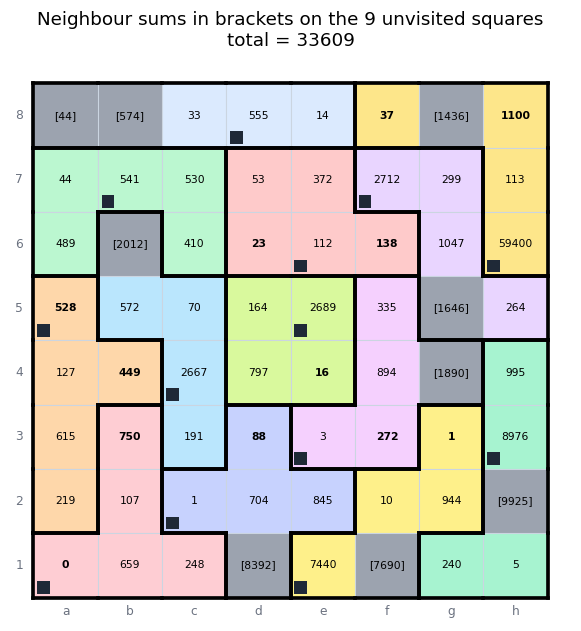

In [19]:
fig, ax = plt.subplots(figsize=(6.6, 6.6))
labels = {**{c: SCORE[c] for c in PATH}, **{c: f"[{s}]" for c, _, s in rows}}
draw_board(ax, cell_text=labels, shade=set(UNVISITED), towers=TOWER, fontsize=7,
           colour_regions=True,
           title=f"Neighbour sums in brackets on the 9 unvisited squares\n"
                 f"total = {answer}")
plt.show()

## 8. Verification

Everything above was produced by one search, so let’s audit the result against the
statement sentence by sentence. Each line either prints `PASS` or raises.

In [20]:
checks = []
def check(label, condition):
    assert condition, f"FAILED: {label}"
    checks.append(label)
    print(f"PASS  {label}")

# --- the board -------------------------------------------------------------
check("13 regions tiling all 64 squares",
      len(groups) == 13 and sum(len(g) for g in groups) == 64)
check("shapes are exactly the 12 pentominoes + one 2x2 tetromino",
      sorted(CATALOGUE[normalise([rc(i) for i in g])] for g in groups) == sorted(PIECES))
check("the 12 printed cells are exactly the cells with ink", set(GIVEN) == set(ink))

# --- towers ----------------------------------------------------------------
check("exactly one tower per region, each inside its own region",
      len(TOWER) == 13 and all(REGION[TOWER[g]] == g for g in range(13)))
check("altitudes are 2 on towers and 1 elsewhere",
      all(ALT[c] == (2 if c in set(TOWER) else 1) for c in PATH))
check("the knight stands on all 13 towers", set(TOWER) <= set(PATH))

# --- the walk --------------------------------------------------------------
check("starts on the bottom-left square", PATH[0] == START == idx(7, 0))
check("never repeats a square", len(set(PATH)) == len(PATH))
check("every move is 0/1/2 in the three dimensions",
      all(sorted((abs(rc(p)[0] - rc(q)[0]), abs(rc(p)[1] - rc(q)[1]),
                  abs(ALT[p] - ALT[q]))) == [0, 1, 2] for p, q in zip(PATH, PATH[1:])))
check("stays on the board", all(0 <= c < NCELLS for c in PATH))

# --- the walk stops at the first moment all towers are covered -------------
first_complete = next(n for n in range(len(PATH)) if set(TOWER) <= set(PATH[:n + 1]))
check(f"the 13th tower is reached on the final move ({first_complete} = {len(PATH) - 1})",
      first_complete == len(PATH) - 1)

# --- scoring ---------------------------------------------------------------
s = 0
for n, p, q, op, expected in LOG:
    if op[0] == "+":
        s += n
    elif op[0] == "x":
        s *= n
    else:
        assert s % n == 0
        s //= n
    assert s == expected == SCORE[q]
check("score arithmetic reproduces every square's value, divisions all exact", s == SCORE[PATH[-1]])

PASS  13 regions tiling all 64 squares
PASS  shapes are exactly the 12 pentominoes + one 2x2 tetromino
PASS  the 12 printed cells are exactly the cells with ink
PASS  exactly one tower per region, each inside its own region
PASS  altitudes are 2 on towers and 1 elsewhere
PASS  the knight stands on all 13 towers
PASS  starts on the bottom-left square
PASS  never repeats a square
PASS  every move is 0/1/2 in the three dimensions
PASS  stays on the board
PASS  the 13th tower is reached on the final move (54 = 54)
PASS  score arithmetic reproduces every square's value, divisions all exact


In [21]:
# --- the recording schedule ------------------------------------------------
check("12 recorded moves for 12 printed numbers",
      len(WRITTEN) == len(GIVEN) == 12)
check("records are 0,3,..,18 then every K=7 moves",
      WRITTEN == [0, 3, 6, 9, 12, 15, 18, 25, 32, 39, 46, 53] and K == 7)
check("every recorded score equals the number printed on that square",
      all(PATH[n] in GIVEN and GIVEN[PATH[n]] == SCORE[PATH[n]] for n in WRITTEN))
check("printed squares are visited on recording moves and never otherwise",
      all((c in GIVEN) == (n in WRITTEN) for n, c in enumerate(PATH)))
check("path length sits in the window forced by 5 late records",
      LAST_RECORD <= len(PATH) - 1 <= MAX_LEN)

# --- uniqueness ------------------------------------------------------------
check("the search found exactly one walk over all K = 1..12", len(all_solutions) == 1)

# --- the answer, recomputed the other way round ----------------------------
alt_total = 0
for cell in PATH:                       # push scores outward instead of pulling
    r, c = rc(cell)
    for dr, dc in ((-1, 0), (1, 0), (0, -1), (0, 1)):
        nr, nc = r + dr, c + dc
        if 0 <= nr < N and 0 <= nc < N and idx(nr, nc) in set(UNVISITED):
            alt_total += SCORE[cell]
check(f"independent recomputation of the answer gives {alt_total}", alt_total == answer)
check("answer is 33609", answer == 33609)

print(f"\n{len(checks)} checks passed.")
print(f"\nANSWER: {answer}")

PASS  12 recorded moves for 12 printed numbers
PASS  records are 0,3,..,18 then every K=7 moves
PASS  every recorded score equals the number printed on that square
PASS  printed squares are visited on recording moves and never otherwise
PASS  path length sits in the window forced by 5 late records
PASS  the search found exactly one walk over all K = 1..12
PASS  independent recomputation of the answer gives 33609
PASS  answer is 33609

20 checks passed.

ANSWER: 33609


## 9. Notes

**Why the search is so quick.** The printed-square rule turns the walk into a
sequence of short hops between *known* squares: after 3 moves the knight must be on
one of eleven specific squares with one specific score, and in between it must avoid
all twelve. Combined with the forced `/N` divisibility and the fact that FLIP moves
have no altitude freedom, the tree collapses to a few million nodes — no
memoisation, no ILP/SAT solver, no tower enumeration.

**Where the difficulty actually sits.** Not in the search, but in noticing that
$|\Delta z| = 2$ is impossible, and hence that towers are a *consequence* of the
walk rather than an input to it. Any approach that guesses tower layouts first is
$10^9$ times more work.

**Reproducing this.** `solver.py` in the same folder is a standalone, dependency-free
version (`python solver.py` prints the walk, both grids and the answer in ~18 s
because it re-runs all twelve values of *K*). This notebook additionally needs
`numpy`, `matplotlib` and `pillow` because it reads the board out of `board.png`.

$$\boxed{\textbf{Answer} = 33609}$$